# `scipy` Optimization
Today we will get an introduction to *optimization*. Optimization is concerned with finding the **best** solution to a problem. For example, finding the shortest driving route or maximizing profit.

Every optimization problem has three components:
- Variables
- Objective function
- Constraints (optional)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Motivating Example
Suppose a company makes chairs. For $x$ amount of chairs, profit is given by
$$P(x)=40x-x^2$$
The question is how many chairs gives the most profit?


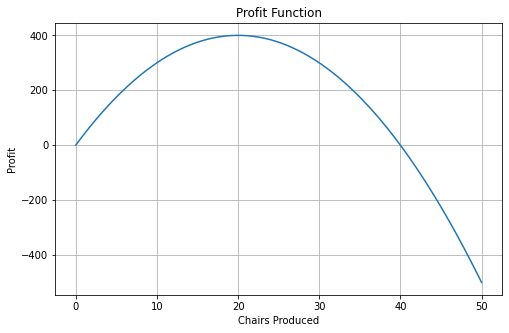

In [2]:

x = np.linspace(0,50,500)

profit = 40*x - x**2

plt.figure(figsize=(8,5))

plt.plot(x,profit)

plt.xlabel("Chairs Produced")
plt.ylabel("Profit")

plt.title("Profit Function")

plt.grid()

plt.show()

The graph reaches its highest point around $x=20$ But we can compute this:

In [3]:
from scipy.optimize import minimize

The `minimize` function will find the minimum. To maximize, we minimize the negative:

In [4]:
def objective(x):
    return -(40*x - x**2)

In [5]:
result = minimize(objective, x0=10)

print(result.x)

[20.00000039]


In [6]:
best_x = result.x[0] # x value that obtains max
maximum_profit = -objective(best_x) # max

print(best_x)
print(maximum_profit)

20.000000385058065
399.9999999999998


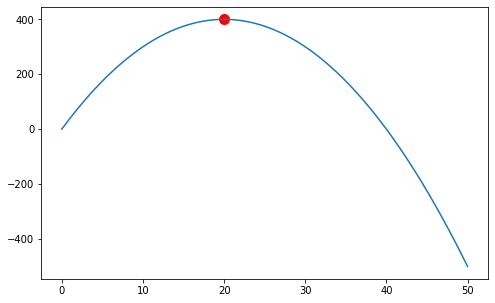

In [7]:
plt.figure(figsize=(8,5))

plt.plot(x,profit)

plt.scatter(best_x,
            maximum_profit,
            color="red",
            s=100)

plt.show()

### Optimization with Two Variables
Suppose

$$
f(x,y)=x^2+y^2
$$

In [8]:
from mpl_toolkits.mplot3d import Axes3D

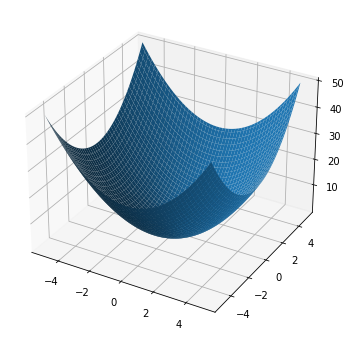

In [9]:
x = np.linspace(-5,5,100)
y = np.linspace(-5,5,100)

X,Y = np.meshgrid(x,y)

Z = X**2 + Y**2

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X,Y,Z)
plt.show()

The minimum appears to occur at $(0,0)$. We can compute:

In [10]:
def f(v):
    x = v[0]
    y = v[1]
    return x**2 + y**2

result = minimize(f,
                  [2,2])

print(result.x)

[-4.75820003e-08 -4.75820001e-08]



### Bounded Optimization
We can also include bounds for our variables

In [12]:
def f(x):
    return -(40*x - x**2)

result = minimize(
    f,
    x0=10,
    bounds=[(0,30)]
)

best_x = result.x[0]
best_profit = 40*best_x - best_x**2

print("Best production =", best_x)
print("Maximum profit =", best_profit)

Best production = 19.99999732853481
Maximum profit = 399.9999999999929


### Multiple Local Minima

Some functions have several minima, so be careful.

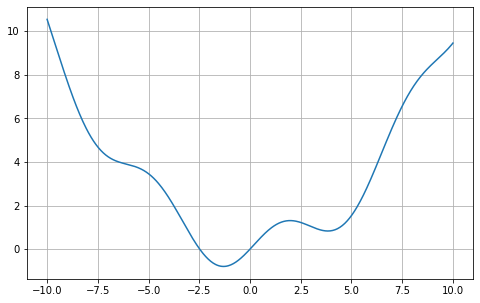

In [13]:
def g(x):
    return np.sin(x)+0.1*x**2

x = np.linspace(-10,10,500)

plt.figure(figsize=(8,5))

plt.plot(x,g(x))

plt.grid()

plt.show()

In [14]:
result1 = minimize(g,-8)

result2 = minimize(g,8)

print(result1.x)
print(result2.x)

[-1.30644013]
[3.8374632]


### Lab Problems


---

1. 
Suppose $f(x)=x^2+6x+10$

a. Plot the function to visualize the minimum

b. Find the minimum using `scipy`


---

2. Find the maximum of $50x-x^2$.

---

3. Minimize

```python
np.sin(x)+x**2
```

using different starting values.

Do you obtain the same solution? Compute the derivative using `sympy`. When is this derivative zero?


---

4. Design a function with multiple minima and optimize.

### Lab Key*

1.

2.

3.

4.